# Company Tickers Analysis

Analysis of `src/sec/output/company_tickers.csv` containing SEC ticker mappings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Load Data
df = pd.read_csv('../output/company_tickers.csv', dtype={'cik': str})

# Preview
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10505, 4)


,cik,name,ticker,exchange
0,1045810,NVIDIA CORP,NVDA,Nasdaq
1,320193,Apple Inc.,AAPL,Nasdaq
2,1652044,Alphabet Inc.,GOOGL,Nasdaq
3,789019,MICROSOFT CORP,MSFT,Nasdaq
4,1018724,AMAZON COM INC,AMZN,Nasdaq


In [3]:
# Basic Statistics
print(f"Total Rows: {len(df)}")
print(f"Unique CIKs: {df['cik'].nunique()}")
print(f"Unique Tickers: {df['ticker'].nunique()}")
print(f"Unique Exchanges: {df['exchange'].nunique()}")

Total Rows: 10505
Unique CIKs: 8231
Unique Tickers: 10504
Unique Exchanges: 4


## Distribution by Exchange

exchange
Nasdaq    4182
NYSE      3274
OTC       2753
CBOE        29
Name: count, dtype: int64


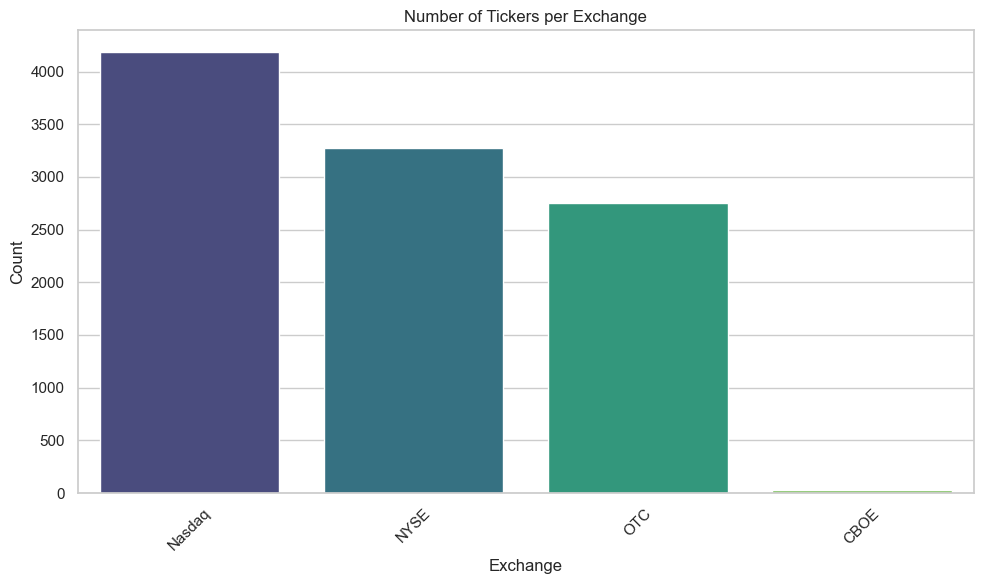

In [4]:
exchange_counts = df['exchange'].value_counts()
print(exchange_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=exchange_counts.index, y=exchange_counts.values, palette="viridis")
plt.title('Number of Tickers per Exchange')
plt.xlabel('Exchange')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Multi-Ticker Companies (CIK Duplicates)
Some CIKs have multiple tickers (e.g. Preferred Stocks).

In [5]:
cik_counts = df['cik'].value_counts()
multi_ticker_ciks = cik_counts[cik_counts > 1]

print(f"Number of Companies (CIKs) with multiple tickers: {len(multi_ticker_ciks)}")
print("\nTop 10 CIKs with most tickers:")
print(multi_ticker_ciks.head(10))

Number of Companies (CIKs) with multiple tickers: 1419

Top 10 CIKs with most tickers:
cik
1026214    25
927971     25
1114446    20
70858      17
1001085    17
310522     16
1415311    16
895728     15
1393311    15
23426      13
Name: count, dtype: int64


In [6]:
# View examples of multi-ticker entries
top_dup_cik = multi_ticker_ciks.index[0]
print(f"Example Entries for CIK {top_dup_cik}:")
df[df['cik'] == top_dup_cik]

Example Entries for CIK 1026214:


,cik,name,ticker,exchange
1240,1026214,FEDERAL HOME LOAN MORTGAGE CORP,FMCC,OTC
7530,1026214,FEDERAL HOME LOAN MORTGAGE CORP,FMCCT,OTC
7705,1026214,FEDERAL HOME LOAN MORTGAGE CORP,FREJO,OTC
7714,1026214,FEDERAL HOME LOAN MORTGAGE CORP,FMCKI,OTC
7732,1026214,FEDERAL HOME LOAN MORTGAGE CORP,FMCCI,OTC
7839,1026214,FEDERAL HOME LOAN MORTGAGE CORP,FMCCG,OTC
7856,1026214,FEDERAL HOME LOAN MORTGAGE CORP,FMCCJ,OTC
7893,1026214,FEDERAL HOME LOAN MORTGAGE CORP,FMCCL,OTC
7895,1026214,FEDERAL HOME LOAN MORTGAGE CORP,FMCKL,OTC
7903,1026214,FEDERAL HOME LOAN MORTGAGE CORP,FMCCS,OTC
